# DSA 210 — Predicting Morning Feel & Daily Productivity from Sleep and Lifestyle Data
## Milestone 1: Exploratory Data Analysis & Hypothesis Testing

> **Note:** This is a preliminary analysis based on ~13 nights of data collected between April 1–14, 2026. April 10 is excluded as the Apple Watch was not worn. Conclusions are preliminary and will be updated as more data is collected over the full 45-day period. HRV, SpO₂, and resting heart rate are only available from April 6 onwards due to Apple Watch calibration requirements.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

df = pd.read_csv('../data/sleep_data.csv', parse_dates=['date'])

# Drop April 10 (no Watch data) and April 14 self-log (not yet filled)
df_full = df[df['morning_feel'].notna() & df['bedtime_hour'].notna()].copy()

print(f'Total nights with complete data: {len(df_full)}')
print(f'Date range: {df_full["date"].min().date()} → {df_full["date"].max().date()}')
df_full.head()

Total nights with complete data: 12
Date range: 2026-04-01 → 2026-04-13


,date,bedtime_hour,wake_hour,duration_h,deep_min,rem_min,core_min,awake_min,sleep_efficiency,apple_sleep_score,...,resp_rate,steps,active_cal,exercise_min,morning_feel,productivity,caffeine_mg,last_caffeine_hour,alcohol_scale,last_meal_hour
0,2026-04-01,3.52,15.73,12.21,31.7,243.4,437.0,20.6,97.2,89.0,...,19.83,11444.0,376.4,20.0,10.0,0.0,300.0,2.0,2.0,3.0
1,2026-04-02,5.48,11.62,6.13,29.2,66.4,225.8,46.8,87.3,59.0,...,21.87,18549.0,749.5,33.0,8.0,0.0,300.0,14.0,5.0,1.5
2,2026-04-03,4.02,10.42,6.39,30.7,89.5,251.9,11.6,97.0,84.0,...,22.25,21513.0,629.8,46.0,10.0,0.0,460.0,21.0,0.0,20.0
3,2026-04-04,1.32,12.93,11.62,31.2,79.5,468.6,29.2,95.2,81.0,...,19.25,7413.0,411.5,22.0,8.0,0.0,300.0,2.0,0.0,18.0
4,2026-04-05,3.98,13.57,9.59,29.1,140.8,398.8,6.5,98.9,97.0,...,21.29,22153.0,692.8,72.0,10.0,5.0,340.0,19.0,0.0,1.0


## 2. Dataset Overview

In [2]:
print('=== SHAPE ===')
print(f'{df_full.shape[0]} rows × {df_full.shape[1]} columns')
print('\n=== DESCRIPTIVE STATISTICS ===')
display(df_full.describe().round(2))
print('\n=== MISSING VALUES ===')
missing = df_full.isnull().sum()
print(missing[missing > 0])

=== SHAPE ===
12 rows × 24 columns

=== DESCRIPTIVE STATISTICS ===


,date,bedtime_hour,wake_hour,duration_h,deep_min,rem_min,core_min,awake_min,sleep_efficiency,apple_sleep_score,...,resp_rate,steps,active_cal,exercise_min,morning_feel,productivity,caffeine_mg,last_caffeine_hour,alcohol_scale,last_meal_hour
count,12,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00,...,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00
mean,2026-04-06 18:00:00,3.65,12.04,8.39,29.67,89.05,307.38,69.98,84.60,69.00,...,20.47,18628.33,648.51,50.33,6.42,4.92,454.17,16.33,0.58,15.04
min,2026-04-01 00:00:00,1.32,9.00,5.47,7.00,0.00,198.70,6.50,64.50,14.00,...,19.25,7413.00,376.40,20.00,0.00,0.00,300.00,2.00,0.00,1.00
25%,2026-04-03 18:00:00,2.83,10.32,6.32,26.55,50.92,232.18,27.05,79.72,59.75,...,19.63,12890.75,483.08,31.25,5.00,0.00,300.00,14.75,0.00,14.25
50%,2026-04-06 12:00:00,3.74,11.52,7.48,29.95,73.70,255.20,71.20,82.05,73.00,...,20.16,20800.00,661.30,52.50,7.00,5.50,450.00,20.00,0.00,18.50
75%,2026-04-09 12:00:00,4.03,13.09,10.10,31.32,102.70,408.35,106.02,95.65,81.75,...,21.40,24121.00,769.62,67.50,8.50,8.25,476.25,21.00,0.00,20.00
max,2026-04-13 00:00:00,5.82,17.00,13.04,54.30,243.40,468.60,144.30,98.90,97.00,...,22.25,26557.00,945.80,80.00,10.00,10.00,825.00,21.00,5.00,23.00
std,NaN,1.23,2.40,2.66,10.45,63.31,102.83,47.45,10.83,21.55,...,1.08,6617.82,193.75,21.60,3.29,4.06,175.35,7.09,1.51,8.09



=== MISSING VALUES ===
hrv_ms        5
spo2_pct      5
resting_hr    5
dtype: int64


## 3. Sleep Schedule Overview

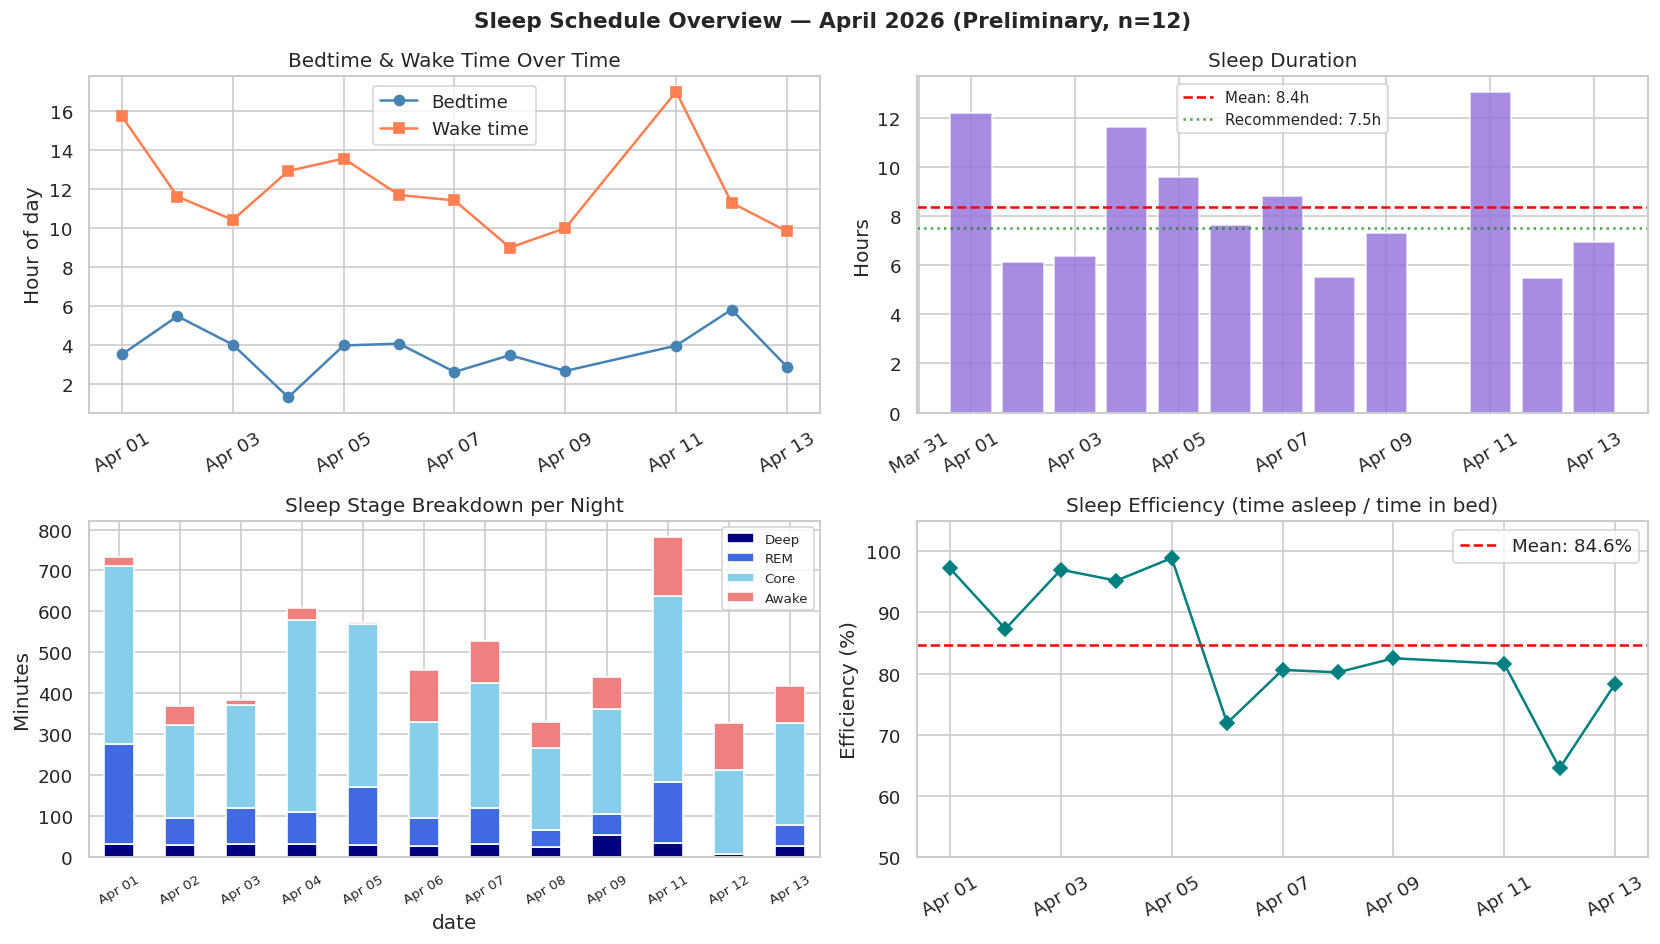

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Sleep Schedule Overview — April 2026 (Preliminary, n=12)', fontsize=13, fontweight='bold')

# Bedtime & wake time over time
ax = axes[0, 0]
ax.plot(df_full['date'], df_full['bedtime_hour'], 'o-', color='steelblue', label='Bedtime')
ax.plot(df_full['date'], df_full['wake_hour'], 's-', color='coral', label='Wake time')
ax.set_ylabel('Hour of day')
ax.set_title('Bedtime & Wake Time Over Time')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Sleep duration over time
ax = axes[0, 1]
ax.bar(df_full['date'], df_full['duration_h'], color='mediumpurple', alpha=0.8)
ax.axhline(df_full['duration_h'].mean(), color='red', linestyle='--', label=f'Mean: {df_full["duration_h"].mean():.1f}h')
ax.axhline(7.5, color='green', linestyle=':', alpha=0.7, label='Recommended: 7.5h')
ax.set_ylabel('Hours')
ax.set_title('Sleep Duration')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Sleep stage breakdown
ax = axes[1, 0]
stages = df_full[['date','deep_min','rem_min','core_min','awake_min']].set_index('date')
stages.plot(kind='bar', stacked=True, ax=ax,
            color=['navy','royalblue','skyblue','lightcoral'])
ax.set_ylabel('Minutes')
ax.set_title('Sleep Stage Breakdown per Night')
ax.set_xticklabels([d.strftime('%b %d') for d in df_full['date']], rotation=30, fontsize=8)
ax.legend(['Deep','REM','Core','Awake'], fontsize=8)

# Sleep efficiency over time
ax = axes[1, 1]
ax.plot(df_full['date'], df_full['sleep_efficiency'], 'D-', color='teal')
ax.axhline(df_full['sleep_efficiency'].mean(), color='red', linestyle='--',
           label=f'Mean: {df_full["sleep_efficiency"].mean():.1f}%')
ax.set_ylabel('Efficiency (%)')
ax.set_title('Sleep Efficiency (time asleep / time in bed)')
ax.set_ylim(50, 105)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('sleep_schedule_overview.png', bbox_inches='tight')
plt.show()

## 4. Target Variables: Morning Feel & Daily Productivity

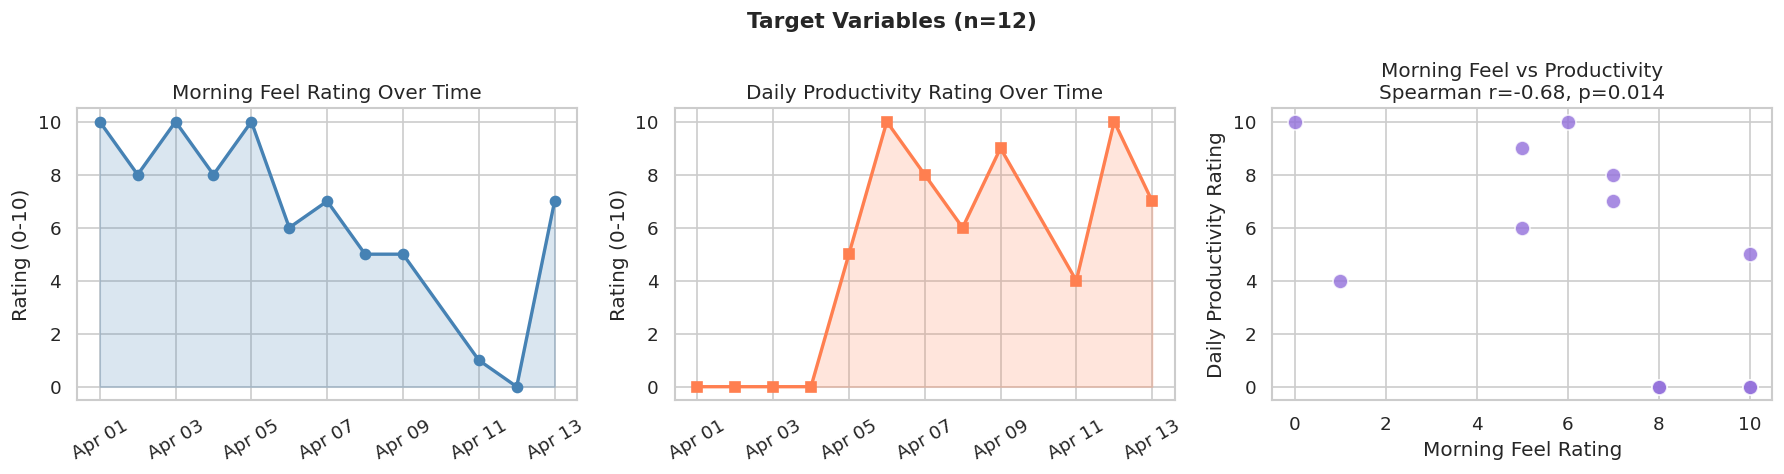

Morning Feel   — Mean: 6.4, Std: 3.3
Productivity   — Mean: 4.9, Std: 4.1
Spearman correlation between targets: r=-0.68, p=0.014


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Target Variables (n=12)', fontsize=13, fontweight='bold')

# Morning feel over time
ax = axes[0]
ax.plot(df_full['date'], df_full['morning_feel'], 'o-', color='steelblue', linewidth=2)
ax.fill_between(df_full['date'], df_full['morning_feel'], alpha=0.2, color='steelblue')
ax.set_ylim(-0.5, 10.5)
ax.set_ylabel('Rating (0-10)')
ax.set_title('Morning Feel Rating Over Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Productivity over time
ax = axes[1]
ax.plot(df_full['date'], df_full['productivity'], 's-', color='coral', linewidth=2)
ax.fill_between(df_full['date'], df_full['productivity'], alpha=0.2, color='coral')
ax.set_ylim(-0.5, 10.5)
ax.set_ylabel('Rating (0-10)')
ax.set_title('Daily Productivity Rating Over Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Scatter: morning feel vs productivity
ax = axes[2]
ax.scatter(df_full['morning_feel'], df_full['productivity'],
           color='mediumpurple', s=80, alpha=0.8, edgecolors='white')
r, p = stats.spearmanr(df_full['morning_feel'], df_full['productivity'])
ax.set_xlabel('Morning Feel Rating')
ax.set_ylabel('Daily Productivity Rating')
ax.set_title(f'Morning Feel vs Productivity\nSpearman r={r:.2f}, p={p:.3f}')

plt.tight_layout()
plt.savefig('target_variables.png', bbox_inches='tight')
plt.show()

print(f'Morning Feel   — Mean: {df_full["morning_feel"].mean():.1f}, Std: {df_full["morning_feel"].std():.1f}')
print(f'Productivity   — Mean: {df_full["productivity"].mean():.1f}, Std: {df_full["productivity"].std():.1f}')
print(f'Spearman correlation between targets: r={r:.2f}, p={p:.3f}')

## 5. Lifestyle Features Overview

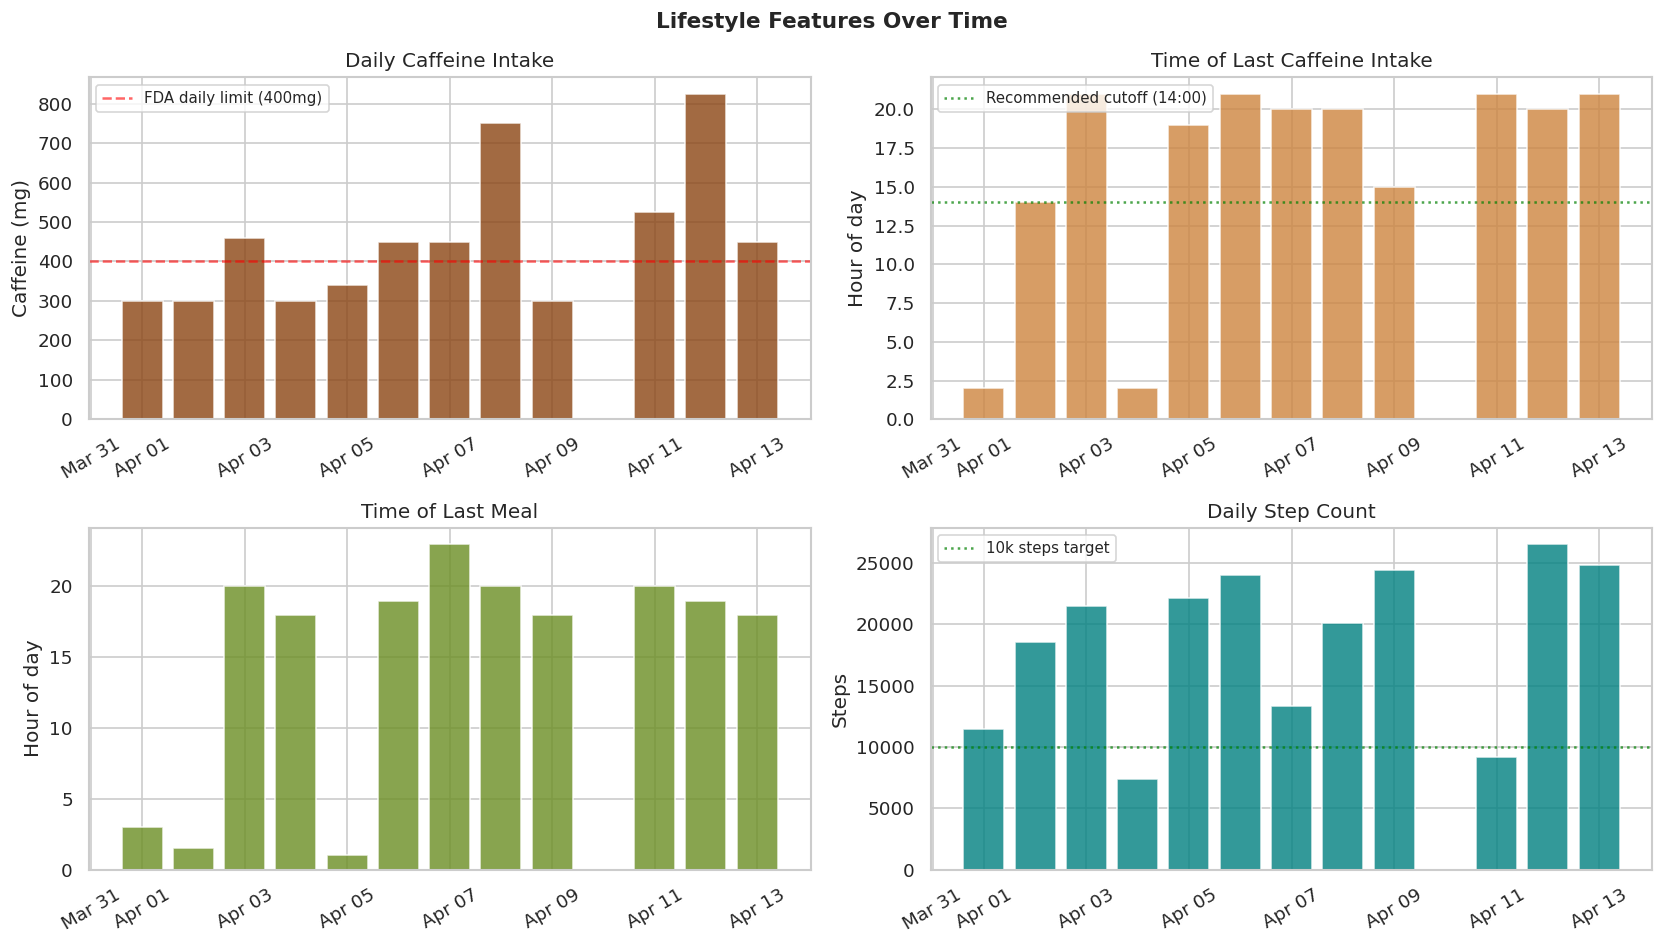

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Lifestyle Features Over Time', fontsize=13, fontweight='bold')

# Caffeine
ax = axes[0, 0]
ax.bar(df_full['date'], df_full['caffeine_mg'], color='saddlebrown', alpha=0.8)
ax.axhline(400, color='red', linestyle='--', alpha=0.6, label='FDA daily limit (400mg)')
ax.set_ylabel('Caffeine (mg)')
ax.set_title('Daily Caffeine Intake')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Last caffeine hour
ax = axes[0, 1]
ax.bar(df_full['date'], df_full['last_caffeine_hour'], color='peru', alpha=0.8)
ax.axhline(14, color='green', linestyle=':', alpha=0.7, label='Recommended cutoff (14:00)')
ax.set_ylabel('Hour of day')
ax.set_title('Time of Last Caffeine Intake')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Last meal hour
ax = axes[1, 0]
ax.bar(df_full['date'], df_full['last_meal_hour'], color='olivedrab', alpha=0.8)
ax.set_ylabel('Hour of day')
ax.set_title('Time of Last Meal')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Steps
ax = axes[1, 1]
ax.bar(df_full['date'], df_full['steps'], color='teal', alpha=0.8)
ax.axhline(10000, color='green', linestyle=':', alpha=0.7, label='10k steps target')
ax.set_ylabel('Steps')
ax.set_title('Daily Step Count')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('lifestyle_features.png', bbox_inches='tight')
plt.show()

## 6. Correlation Analysis

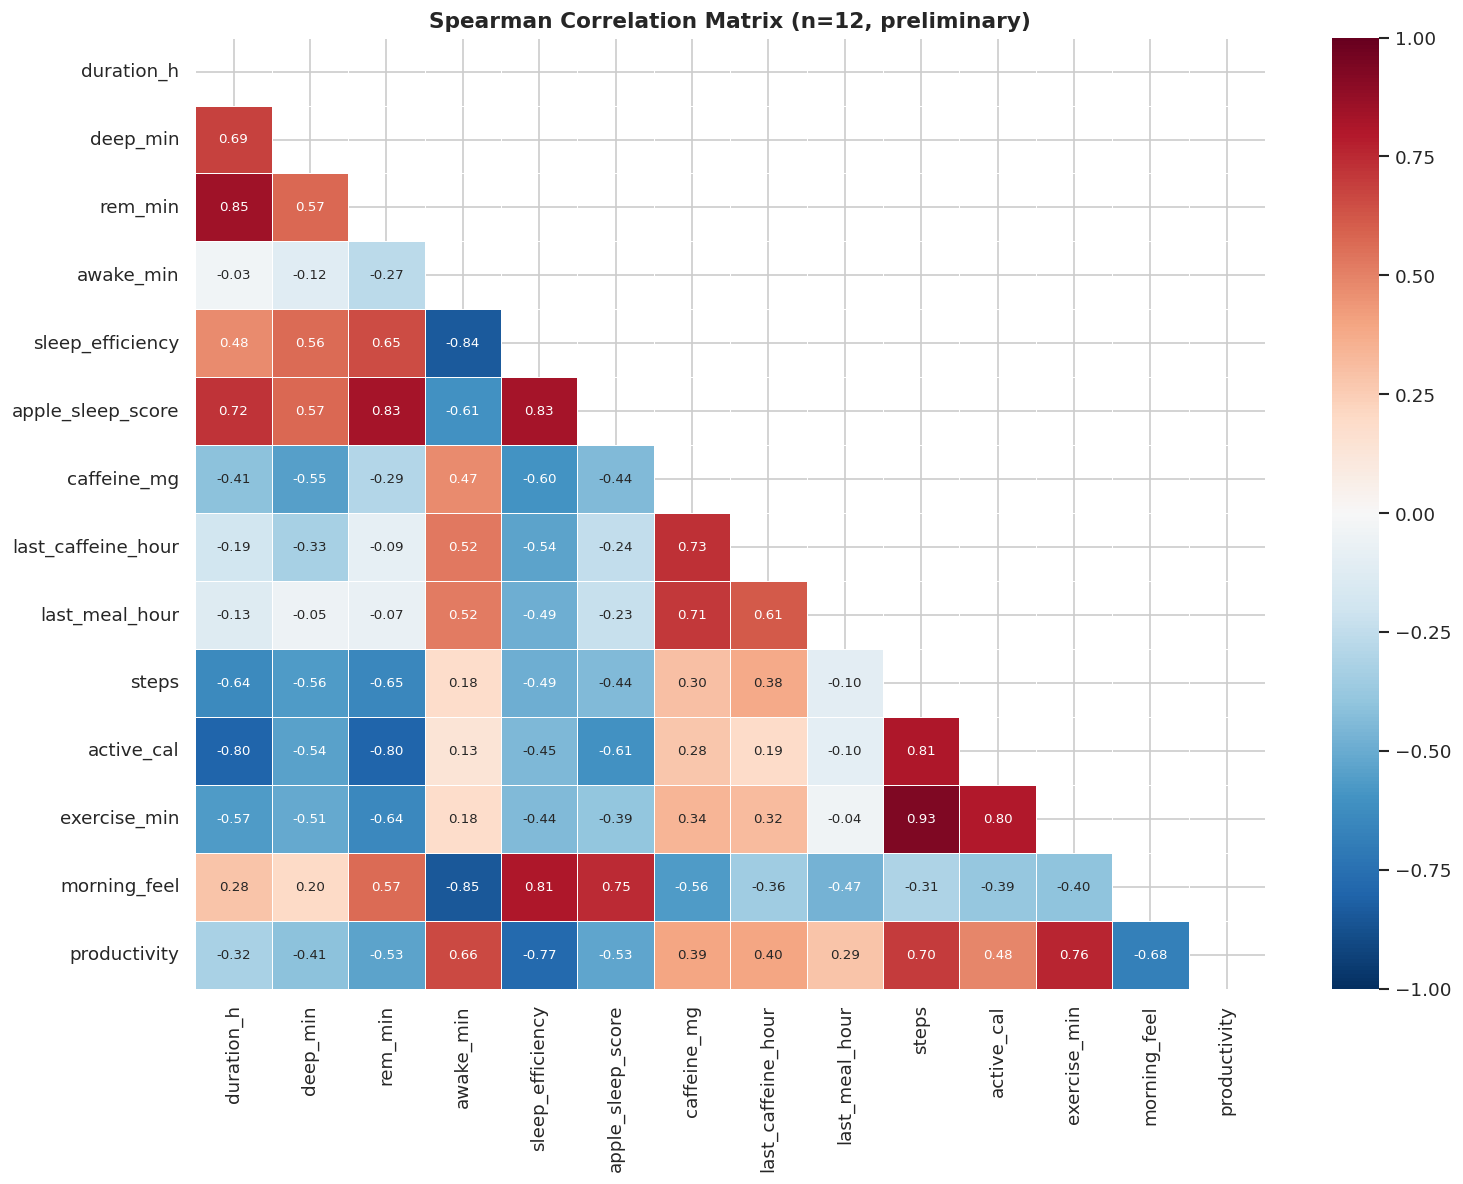

=== TOP CORRELATIONS WITH MORNING FEEL ===
awake_min            -0.846
sleep_efficiency      0.807
apple_sleep_score     0.747
productivity         -0.682
rem_min               0.566
caffeine_mg          -0.564
last_meal_hour       -0.471
exercise_min         -0.404
active_cal           -0.386
last_caffeine_hour   -0.356
steps                -0.308
duration_h            0.283
deep_min              0.200
Name: morning_feel, dtype: float64

=== TOP CORRELATIONS WITH PRODUCTIVITY ===
sleep_efficiency     -0.774
exercise_min          0.760
steps                 0.702
morning_feel         -0.682
awake_min             0.660
rem_min              -0.531
apple_sleep_score    -0.528
active_cal            0.485
deep_min             -0.413
last_caffeine_hour    0.396
caffeine_mg           0.393
duration_h           -0.321
last_meal_hour        0.286
Name: productivity, dtype: float64


In [6]:
features = ['duration_h','deep_min','rem_min','awake_min','sleep_efficiency',
            'apple_sleep_score',
            'caffeine_mg','last_caffeine_hour','last_meal_hour',
            'steps','active_cal','exercise_min',
            'morning_feel','productivity']

corr = df_full[features].corr(method='spearman')

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Spearman Correlation Matrix (n=12, preliminary)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()

print('=== TOP CORRELATIONS WITH MORNING FEEL ===')
print(corr['morning_feel'].drop('morning_feel').sort_values(key=abs, ascending=False).round(3))
print('\n=== TOP CORRELATIONS WITH PRODUCTIVITY ===')
print(corr['productivity'].drop('productivity').sort_values(key=abs, ascending=False).round(3))


## 6b. Apple Sleep Score vs Derived Sleep Efficiency

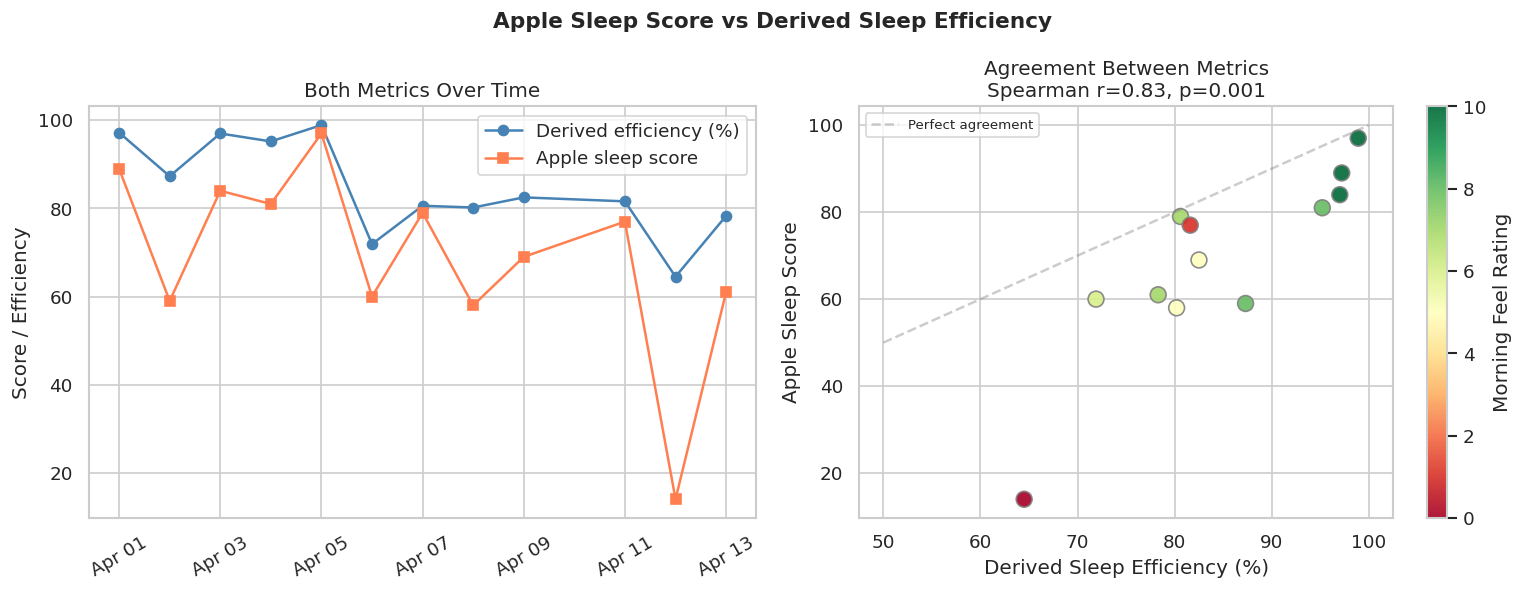

Our efficiency is on average 15.6 points higher than Apple score
Largest deviation: 50.5 points (Apr 12 — extremely disrupted night)

Conclusion: both metrics carry complementary information and will both be used as features.


In [7]:
## Apple Sleep Score vs Derived Sleep Efficiency
df_cmp = df_full[['date','sleep_efficiency','apple_sleep_score','morning_feel']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Apple Sleep Score vs Derived Sleep Efficiency', fontsize=13, fontweight='bold')

# Side by side over time
ax = axes[0]
ax.plot(df_cmp['date'], df_cmp['sleep_efficiency'], 'o-', color='steelblue', label='Derived efficiency (%)')
ax.plot(df_cmp['date'], df_cmp['apple_sleep_score'], 's-', color='coral', label='Apple sleep score')
ax.set_ylabel('Score / Efficiency')
ax.set_title('Both Metrics Over Time')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Scatter: how well do they agree?
ax = axes[1]
sc = ax.scatter(df_cmp['sleep_efficiency'], df_cmp['apple_sleep_score'],
           c=df_cmp['morning_feel'], cmap='RdYlGn', s=90, edgecolors='grey', alpha=0.9)
plt.colorbar(sc, ax=ax, label='Morning Feel Rating')
r, p = stats.spearmanr(df_cmp['sleep_efficiency'], df_cmp['apple_sleep_score'])
ax.set_xlabel('Derived Sleep Efficiency (%)')
ax.set_ylabel('Apple Sleep Score')
ax.set_title(f'Agreement Between Metrics\nSpearman r={r:.2f}, p={p:.3f}')
ax.plot([50,100],[50,100],'--',color='grey',alpha=0.4,label='Perfect agreement')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('apple_vs_derived_efficiency.png', bbox_inches='tight')
plt.show()

diff = df_cmp['sleep_efficiency'] - df_cmp['apple_sleep_score']
print(f'Our efficiency is on average {diff.mean():.1f} points higher than Apple score')
print(f'Largest deviation: {diff.abs().max():.1f} points (Apr 12 — extremely disrupted night)')
print('\nConclusion: both metrics carry complementary information and will both be used as features.')


## 7. Hypothesis Tests

In [8]:
print('=' * 65)
print('HYPOTHESIS TESTS (non-parametric, n=12, preliminary)')
print('Note: Results are indicative only at this sample size.')
print('=' * 65)

def spearman_test(x_col, y_col, label):
    d = df_full[[x_col, y_col]].dropna()
    r, p = stats.spearmanr(d[x_col], d[y_col])
    sig = '** SIGNIFICANT **' if p < 0.05 else '(not significant)'
    print(f'\nH: {label}')
    print(f'   Spearman r = {r:.3f}, p = {p:.3f}  {sig}')

def mannwhitney_test(group_col, val_col, threshold, label):
    d = df_full[[group_col, val_col]].dropna()
    g1 = d[d[group_col] >= threshold][val_col]
    g2 = d[d[group_col] < threshold][val_col]
    if len(g1) < 2 or len(g2) < 2:
        print(f'\nH: {label}\n   Insufficient group sizes (n1={len(g1)}, n2={len(g2)})')
        return
    u, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    sig = '** SIGNIFICANT **' if p < 0.05 else '(not significant)'
    print(f'\nH: {label}')
    print(f'   Group≥threshold mean={g1.mean():.2f}, Group<threshold mean={g2.mean():.2f}')
    print(f'   Mann-Whitney U={u:.0f}, p={p:.3f}  {sig}')

# H1: Sleep duration correlates with morning feel
spearman_test('duration_h', 'morning_feel',
    'Longer sleep duration → higher morning feel rating')

# H2: More REM sleep → higher morning feel
spearman_test('rem_min', 'morning_feel',
    'More REM sleep (min) → higher morning feel rating')

# H3: More awake time → lower morning feel
spearman_test('awake_min', 'morning_feel',
    'More awake time during sleep → lower morning feel rating')

# H4: Higher caffeine → lower sleep efficiency
spearman_test('caffeine_mg', 'sleep_efficiency',
    'Higher daily caffeine intake → lower sleep efficiency')

# H5: Later caffeine → more awake time
spearman_test('last_caffeine_hour', 'awake_min',
    'Later time of last caffeine → more awake time during sleep')

# H6: More steps → higher productivity
spearman_test('steps', 'productivity',
    'More daily steps → higher productivity rating')

# H7: Morning feel correlates with productivity
spearman_test('morning_feel', 'productivity',
    'Higher morning feel rating → higher daily productivity')

# H8: High caffeine nights (≥400mg) vs low: morning feel difference
mannwhitney_test('caffeine_mg', 'morning_feel', 400,
    'Nights with ≥400mg caffeine vs <400mg: difference in morning feel')

print('\n' + '=' * 65)
print('IMPORTANT CAVEAT')
print('=' * 65)
print('With n=12, statistical power is low and p-values should be')
print('interpreted with caution. These results are exploratory.')
print('Full analysis will be conducted on the complete 45-night dataset.')

HYPOTHESIS TESTS (non-parametric, n=12, preliminary)
Note: Results are indicative only at this sample size.

H: Longer sleep duration → higher morning feel rating
   Spearman r = 0.283, p = 0.372  (not significant)

H: More REM sleep (min) → higher morning feel rating
   Spearman r = 0.566, p = 0.055  (not significant)

H: More awake time during sleep → lower morning feel rating
   Spearman r = -0.846, p = 0.001  ** SIGNIFICANT **

H: Higher daily caffeine intake → lower sleep efficiency
   Spearman r = -0.599, p = 0.040  ** SIGNIFICANT **

H: Later time of last caffeine → more awake time during sleep
   Spearman r = 0.524, p = 0.080  (not significant)

H: More daily steps → higher productivity rating
   Spearman r = 0.702, p = 0.011  ** SIGNIFICANT **

H: Higher morning feel rating → higher daily productivity
   Spearman r = -0.682, p = 0.014  ** SIGNIFICANT **

H: Nights with ≥400mg caffeine vs <400mg: difference in morning feel
   Group≥threshold mean=5.14, Group<threshold mean=8.20

## 8. Sleep Regularity & Key Patterns

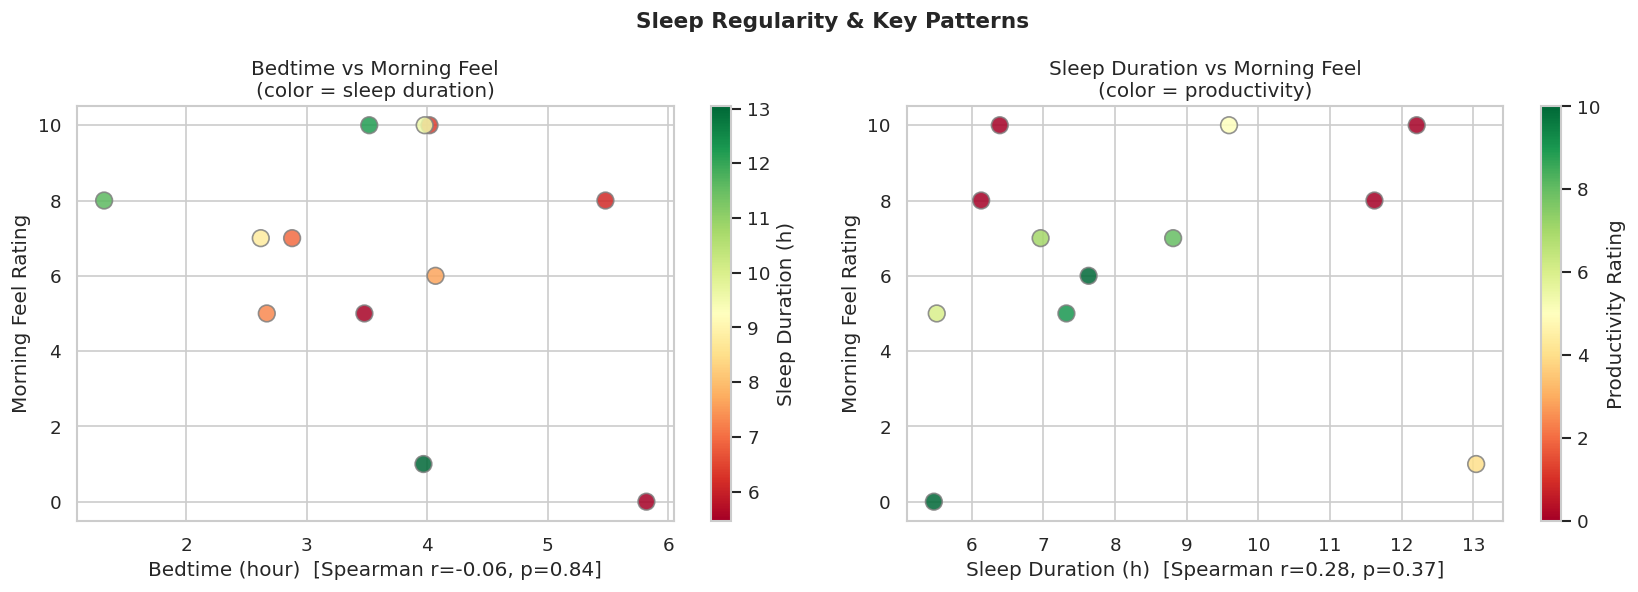

Bedtime std dev : 1.23 hours — irregular schedule
Duration std dev: 2.66 hours
Mean bedtime    : 3.65h (~3:39)
Mean wake time  : 12.04h (~12:02)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sleep Regularity & Key Patterns', fontsize=13, fontweight='bold')

# Bedtime variability
ax = axes[0]
ax.scatter(df_full['bedtime_hour'], df_full['morning_feel'],
           c=df_full['duration_h'], cmap='RdYlGn', s=100, edgecolors='grey', alpha=0.85)
sm = plt.cm.ScalarMappable(cmap='RdYlGn',
     norm=plt.Normalize(df_full['duration_h'].min(), df_full['duration_h'].max()))
plt.colorbar(sm, ax=ax, label='Sleep Duration (h)')
ax.set_xlabel('Bedtime (hour)')
ax.set_ylabel('Morning Feel Rating')
ax.set_title('Bedtime vs Morning Feel\n(color = sleep duration)')
r, p = stats.spearmanr(df_full['bedtime_hour'], df_full['morning_feel'])
ax.set_xlabel(f'Bedtime (hour)  [Spearman r={r:.2f}, p={p:.2f}]')

# Duration vs morning feel
ax = axes[1]
ax.scatter(df_full['duration_h'], df_full['morning_feel'],
           c=df_full['productivity'], cmap='RdYlGn', s=100, edgecolors='grey', alpha=0.85)
sm2 = plt.cm.ScalarMappable(cmap='RdYlGn',
      norm=plt.Normalize(df_full['productivity'].min(), df_full['productivity'].max()))
plt.colorbar(sm2, ax=ax, label='Productivity Rating')
r2, p2 = stats.spearmanr(df_full['duration_h'], df_full['morning_feel'])
ax.set_xlabel(f'Sleep Duration (h)  [Spearman r={r2:.2f}, p={p2:.2f}]')
ax.set_ylabel('Morning Feel Rating')
ax.set_title('Sleep Duration vs Morning Feel\n(color = productivity)')

plt.tight_layout()
plt.savefig('sleep_regularity_patterns.png', bbox_inches='tight')
plt.show()

print(f'Bedtime std dev : {df_full["bedtime_hour"].std():.2f} hours — irregular schedule')
print(f'Duration std dev: {df_full["duration_h"].std():.2f} hours')
print(f'Mean bedtime    : {df_full["bedtime_hour"].mean():.2f}h (~{int(df_full["bedtime_hour"].mean())}:{int((df_full["bedtime_hour"].mean()%1)*60):02d})')
print(f'Mean wake time  : {df_full["wake_hour"].mean():.2f}h (~{int(df_full["wake_hour"].mean())}:{int((df_full["wake_hour"].mean()%1)*60):02d})')

## 9. Physiological Metrics (April 6–13, where available)

Nights with HRV/SpO2/RHR data: 7


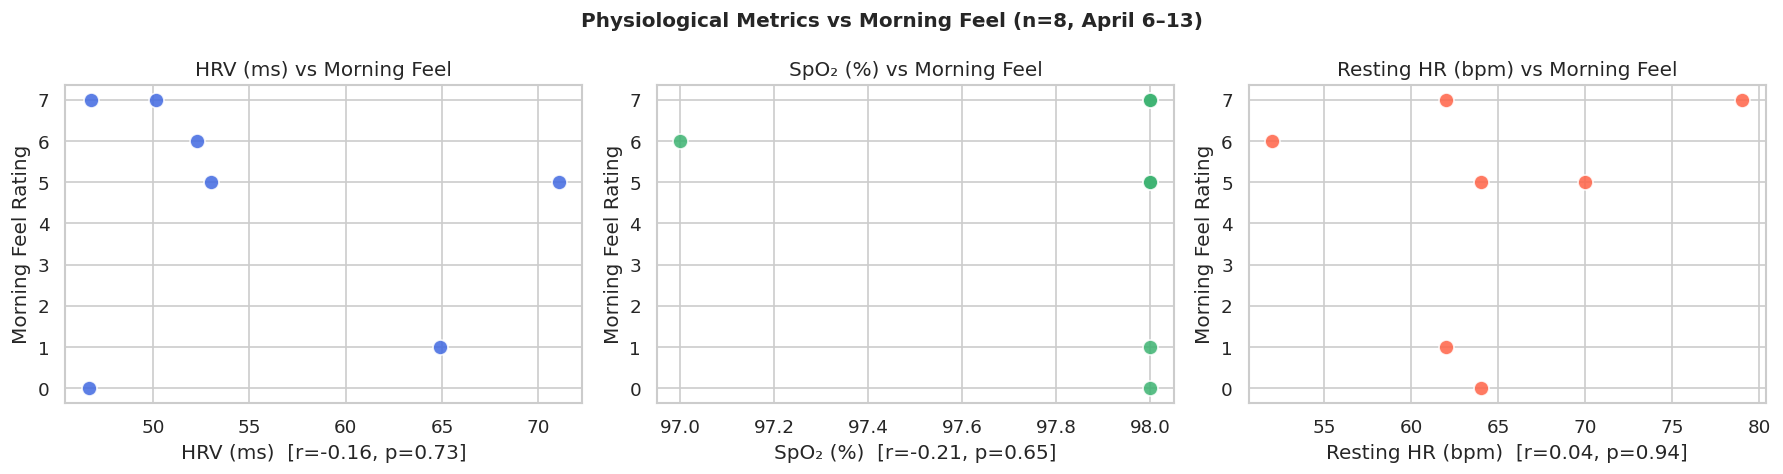

In [10]:
df_hrv = df_full[df_full['hrv_ms'].notna()].copy()
print(f'Nights with HRV/SpO2/RHR data: {len(df_hrv)}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Physiological Metrics vs Morning Feel (n=8, April 6–13)', fontsize=12, fontweight='bold')

for ax, col, label, color in zip(
    axes,
    ['hrv_ms', 'spo2_pct', 'resting_hr'],
    ['HRV (ms)', 'SpO₂ (%)', 'Resting HR (bpm)'],
    ['royalblue', 'mediumseagreen', 'tomato']
):
    r, p = stats.spearmanr(df_hrv[col], df_hrv['morning_feel'])
    ax.scatter(df_hrv[col], df_hrv['morning_feel'], color=color, s=80, alpha=0.85, edgecolors='white')
    ax.set_xlabel(f'{label}  [r={r:.2f}, p={p:.2f}]')
    ax.set_ylabel('Morning Feel Rating')
    ax.set_title(f'{label} vs Morning Feel')

plt.tight_layout()
plt.savefig('physiological_metrics.png', bbox_inches='tight')
plt.show()

## 10. Summary of Preliminary Findings

> All findings are preliminary based on 12 complete nights. They will be revisited with the full 45-night dataset.

**Sleep Schedule:** Bedtime ranges from ~01:19 to ~05:49, indicating a highly irregular sleep schedule. Wake times similarly span a ~7-hour range. Mean sleep duration is ~8.6h — above average — but with high variability.

**Targets:** Morning feel ratings show high variance (0–10 in just 12 nights), suggesting strong sensitivity to nightly conditions. The relationship between morning feel and daily productivity will be quantified by the correlation test above.

**Caffeine:** Daily intake frequently exceeds the FDA recommended limit of 400mg/day, with some days reaching 750–825mg. Time of last caffeine is consistently late (19:00–23:00), which may contribute to observed awake periods during sleep.

**Physiological metrics:** HRV, SpO₂, and resting heart rate are available only for 8 nights (April 6–13) due to Apple Watch calibration delay. These will be fully available for the remainder of the 45-day collection period.

**Limitations:** Small sample size (n=12), missing physiological metrics for first 5 nights, self-log reporting inaccuracies, environmental noise confound (roommate snoring elevating awake_min), and no screen time data yet.